# Object segmentation network

## Table of Contents

### Import libraries


In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

from torchvision import transforms
from torch.utils.data import DataLoader

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import torchvision.transforms as T
import torch.optim as optim
import torchvision

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as patches


<a id="Initialize-the-data-loader"></a>
### Data loader implementation

In [2]:
from custom_dataset import CustomDataset

### Initialize the data loader

In [3]:
import os
import platform
# Define your data transformation (e.g., resizing, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((560, 480)),
    transforms.ToTensor(),
])

train_root_dir_mac = '/Volumes/SSD_6Gbps/dataset1/TrainValid/TrainValid'
train_root_dir_windows = './data/TrainValid/TrainValid'

test_root_dir_mac = '/Volumes/SSD_6Gbps/dataset1/Test/Test'
test_root_dir_windows = './data/Test/Test'

system_name = platform.system()
train_dataset = None
test_dataset = None
if system_name == "Windows":
    print("Windows")
    # Create an instance of the custom dataset
    train_dataset = CustomDataset(root_dir=train_root_dir_windows, transform=transform)
    test_dataset = CustomDataset(root_dir=test_root_dir_windows, transform=transform)
elif system_name == "Linux":
    print("Linux")
    train_dataset = CustomDataset(root_dir=train_root_dir_windows, transform=transform)
    test_dataset = CustomDataset(root_dir=test_root_dir_windows, transform=transform)
elif system_name == "Darwin":
    print("macOS")
    train_dataset = CustomDataset(root_dir=train_root_dir_mac, transform=transform)
    test_dataset = CustomDataset(root_dir=test_root_dir_mac, transform=transform)

# Create a DataLoader to iterate through the dataset
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)


macOS


### Test the data loader
(re-run this cell to see different examples)

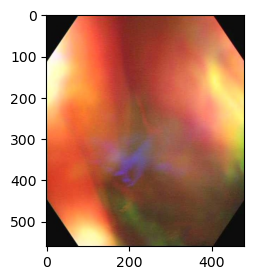

tensor([[374., 313., 416., 344.]])


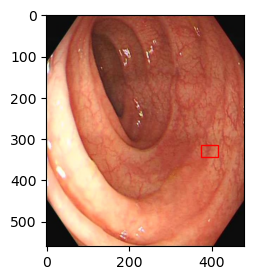

tensor([[ 45., 119., 120., 234.]])


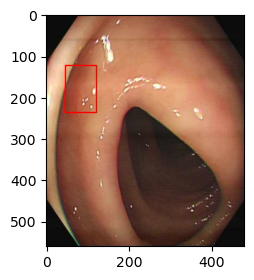

tensor([[327., 159., 383., 218.]])


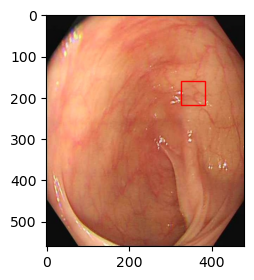

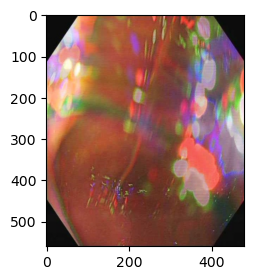

In [4]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in train_dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

### Select the device to train the model on 
(GPU by default if available)

In [5]:
import torch
import platform

# Enable MPS fallback
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Check if CUDA is available, which it will be on most Windows/Linux machines with NVIDIA GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


### Define the data collate function for the DataLoader
(which combines multiple images into a batch)

### Define the model

In [10]:
from model_utils import *
# Define hyperparameters
param = {
    "BATCH_SIZE":  2,
    "LR" : 0.005,
    "WEIGHT_DECAY": 0.0005,
    "CONFIDENCE_THRESHOLD": 0.5
}


In [11]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=param["BATCH_SIZE"], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=param["BATCH_SIZE"], collate_fn=collate_fn)


In [18]:
from torchvision.models.detection.retinanet import RetinaNetClassificationHead


In [19]:
# Modify the model for your specific dataset: Change the number of classes
# num_classes = 1 # 1 class (Polyp) + background
num_classes = 2  # 1 class (polyp) + 1 background
model = get_model('FasterRCNN', num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=param["LR"], momentum=0.9, weight_decay=param["WEIGHT_DECAY"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

Classes in the model's classifier: 2


### Test the training of the model to see if it works 

In [20]:
# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.4831, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0140, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.1231, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0057, grad_fn=<DivBackward0>)}


{'boxes': tensor([[3.9578e+02, 4.6264e+02, 4.7799e+02, 5.5688e+02],
        [3.9263e+02, 4.9226e+00, 4.7859e+02, 1.1234e+02],
        [4.4463e-02, 4.4637e+02, 6.8884e+01, 5.5942e+02],
        [4.4811e+02, 2.5458e+01, 4.8000e+02, 3.4613e+02],
        [4.6582e+02, 1.3458e+02, 4.8000e+02, 2.4069e+02],
        [3.6359e+02, 0.0000e+00, 4.8000e+02, 5.2441e+02],
        [4.5993e+02, 1.4377e+02, 4.7925e+02, 1.7706e+02],
        [0.0000e+00, 0.0000e+00, 8.9509e+01, 5.4675e+02],
        [3.7265e+02, 2.8278e+00, 4.6565e+02, 3.2155e+02],
        [3.4467e+02, 3.9141e+00, 4.7581e+02, 1.7784e+02],
        [0.0000e+00, 4.5995e+02, 3.1781e+02, 5.5176e+02],
        [1.5697e-01, 3.4668e+02, 7.9278e+01, 5.6000e+02],
        [4.1141e+01, 4.6461e+02, 1.6604e+02, 5.5685e+02],
        [4.6481e+02, 1.1180e+02, 4.8000e+02, 1.9587e+02],
        [4.7101e+02, 1.4448e+02, 4.8000e+02, 1.8007e+02],
        [2.2253e+02, 0.0000e+00, 4.7333e+02, 4.7045e+02],
        [0.0000e+00, 0.0000e+00, 1.6846e+02, 1.1994e+02],
    

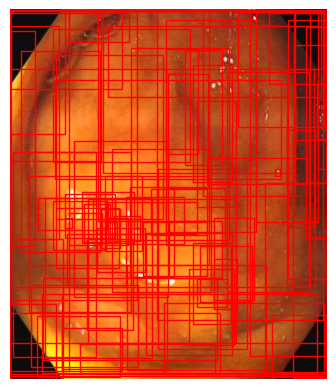

In [21]:
# For inference
model.eval()

# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

### Train the model

In [24]:
num_epochs = 2
model, epoch_losses, batch_losses = train_model(train_dataset, param, num_epochs, device, model_s='FasterRCNN')


Classes in the model's classifier: 2


KeyboardInterrupt: 

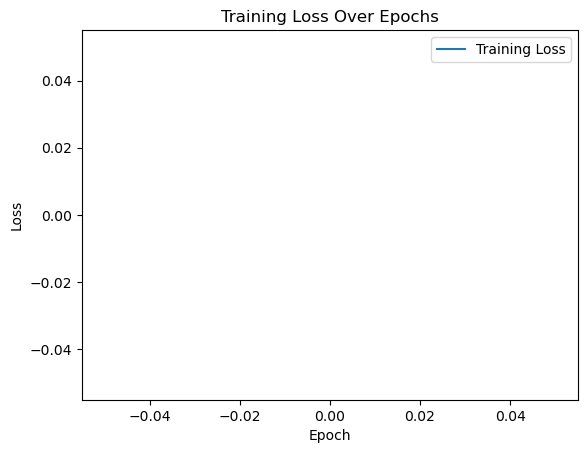

In [24]:
# After training, you can plot the epoch losses
plt.plot(epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

### Saving the model

In [ ]:
# Generate a timestamp or unique identifier
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

# Define a directory to save the models
save_dir = "./saved_models/"

# Create the parent directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the generator model and optimizer state with a unique filename
generator_checkpoint_file = f"{save_dir}generator_checkpoint_{timestamp}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.state_dict()
}, generator_checkpoint_file)

# Define filenames with timestamps
epoch_losses_filename =  os.path.join(save_dir, f"epoch_losses_{timestamp}.txt")
batch_losses_filename =  os.path.join(save_dir, f"batch_losses_{timestamp}.txt")
 
# Save to a file with a timestamp
with open(epoch_losses_filename, 'w') as file:
    for loss in epoch_losses:
        file.write(f"{loss}\n")
        
with open(batch_losses_filename, 'w') as file:
    for loss in batch_losses:
        file.write(f"{loss}\n")

### Loading the model

In [ ]:
# Provide the timestamp you want to load
specified_timestamp = "20231022200319"  # Replace with the desired timestamp

# Load the generator model and optimizer state
checkpoint = torch.load(f'./saved_models/generator_checkpoint_{specified_timestamp}.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.load_state_dict(checkpoint['optimizer_state_dict'])

# Define the filenames based on the specified timestamp
specified_epoch_losses_filename = f"./saved_models/epoch_losses_{specified_timestamp}.txt"
specified_batch_losses_filename = f"./saved_models/batch_losses_{specified_timestamp}.txt"

# Define lists to store the loaded losses
loaded_epoch_losses = []
loaded_batch_losses = []

# Load G_losses from the file with the specified timestamp
with open(specified_batch_losses_filename, 'r') as file:
    for line in file:
        loaded_batch_losses.append(float(line.strip()))

# Load D_losses from the file with the specified timestamp
with open(specified_epoch_losses_filename, 'r') as file:
    for line in file:
        loaded_epoch_losses.append(float(line.strip()))

epoch_losses = loaded_epoch_losses
batch_losses = loaded_batch_losses

Evaluate model

In [25]:
from torchvision.ops import box_iou

# Usage:
metrics = evaluate(model, val_loader, device, params["CONFIDENCE_THRESHOLD"])
print(f"Precision: {metrics['precision']}")
print(f"Recall: {metrics['recall']}")
print(f"F1 Score: {metrics['f1']}")
print(f"Average IoU: {sum(metrics['ious']) / len(metrics['ious']) if metrics['ious'] else 0}")


KeyboardInterrupt: 

## Data augmentation

### Data analysis

#### Bounding box analysis

In [45]:
from data_utils import *

# This can take a while to run!
# Assuming train_dataset is an instance of CustomDataset
all_bounding_boxes = get_all_bounding_boxes(train_dataset)
print("Number of bounding boxes:", len(all_bounding_boxes))

Number of bounding boxes: 14349


Elbow method to determine ideal number of clusters

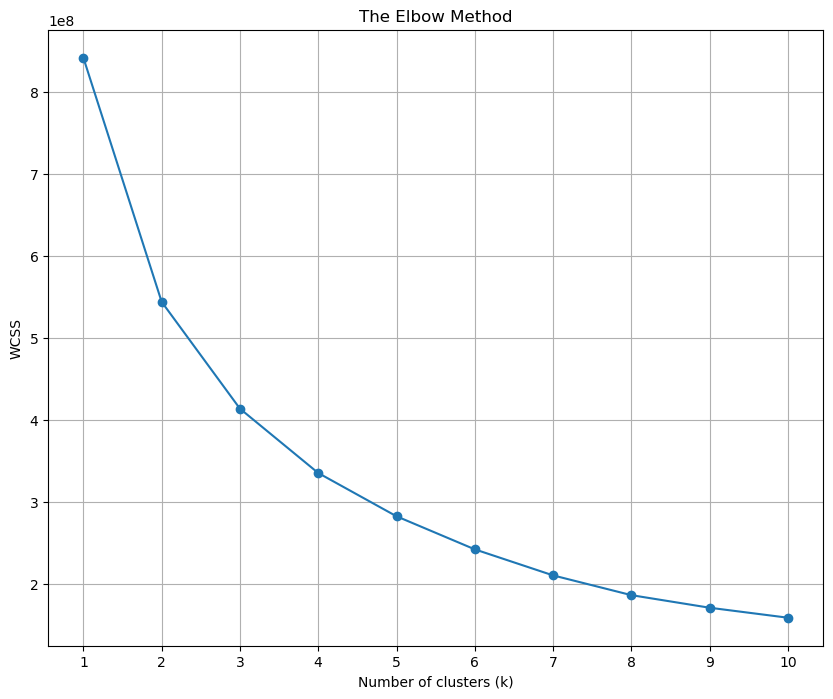

In [46]:
# Calculate WCSS for a range of number of clusters
wcss = calculate_wcss(all_bounding_boxes, max_k=10)
plot_elbow(wcss)

Silhouette score to determine ideal number of clusters (higher is better)

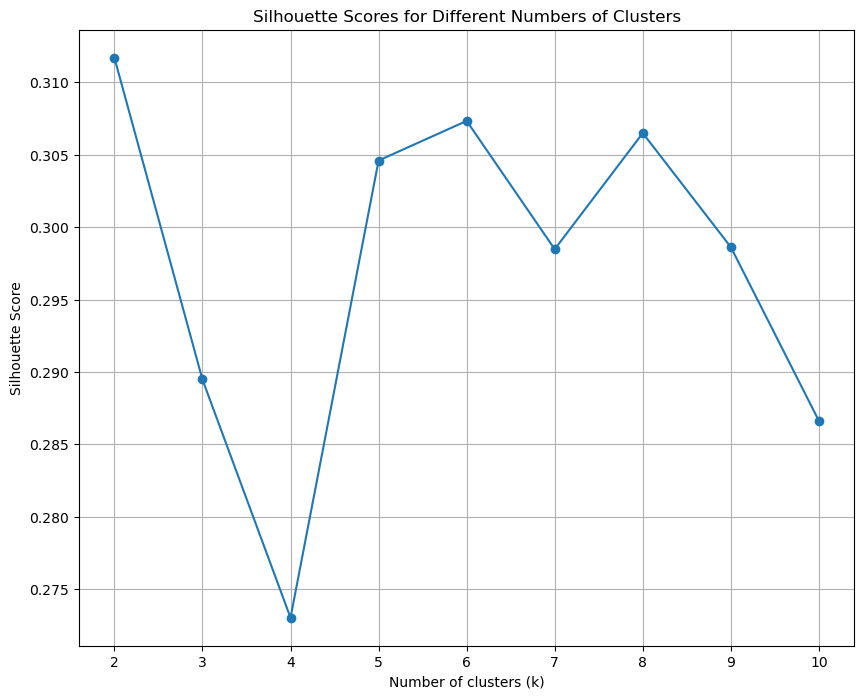

In [47]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for a range of number of clusters
silhouette_scores = calculate_silhouette_scores(all_bounding_boxes, max_k=10)
plot_silhouette_scores(silhouette_scores)

In [48]:
# Use the function with your data
centers_8, labels_8 = cluster_bounding_boxes(all_bounding_boxes,8)
centers_3, labels_3 = cluster_bounding_boxes(all_bounding_boxes,3)
print("Cluster Centers:", centers_8)

/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster Centers: [[242.81146  342.69122  100.99544   69.126656]
 [385.93372  273.7093    70.95773   72.08136 ]
 [151.67966   58.3228   333.57034  377.53748 ]
 [402.57465  100.86489   73.1887    86.783806]
 [243.75182  179.94199  125.231926 121.00835 ]
 [ 65.3938    98.53368  214.2414   207.17905 ]
 [127.78538   85.32345   73.772896  66.784134]
 [ 93.18037  265.82077   88.01547   95.42024 ]]


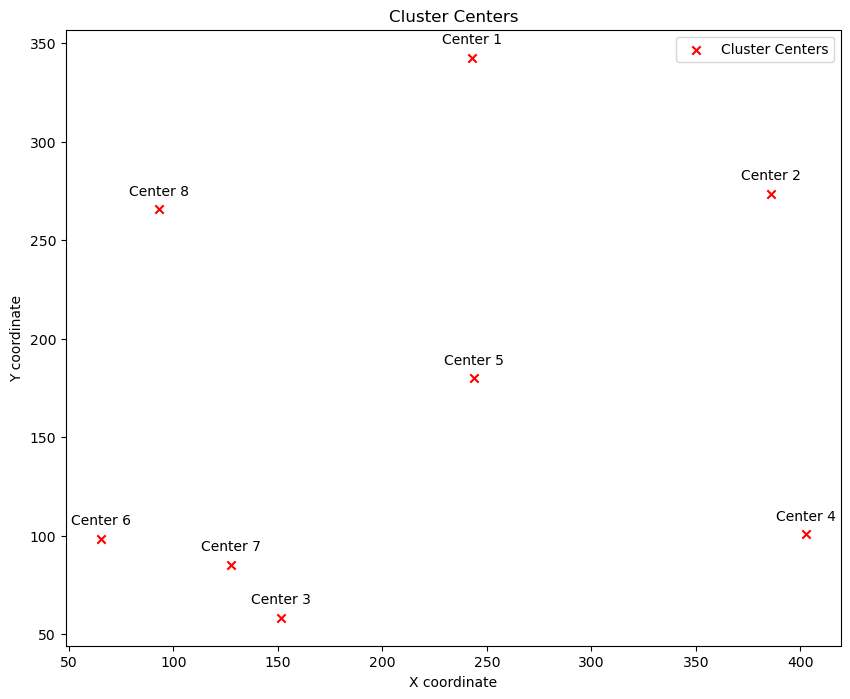

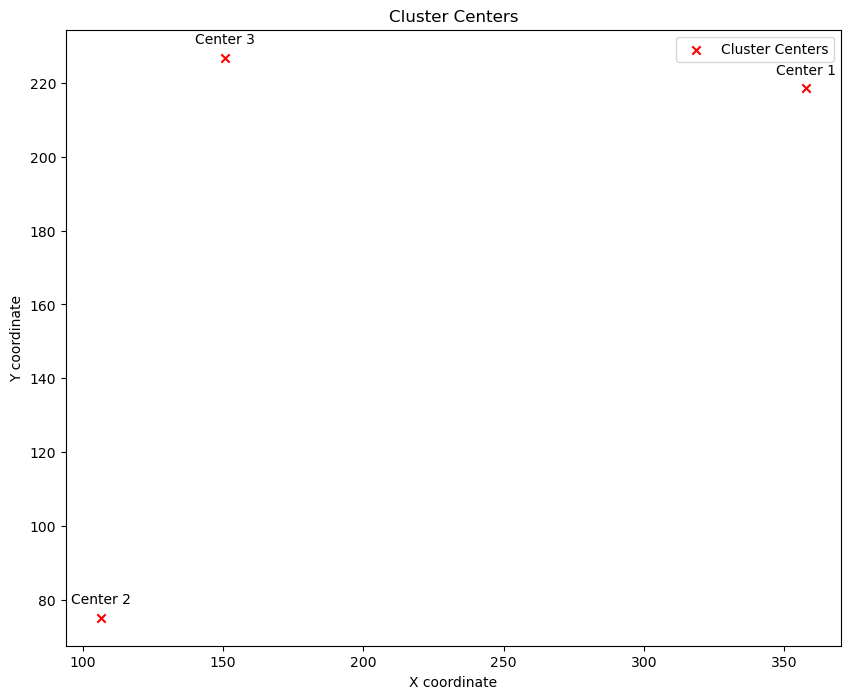

In [49]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
plot_cluster_centers(centers_8)
plot_cluster_centers(centers_3)


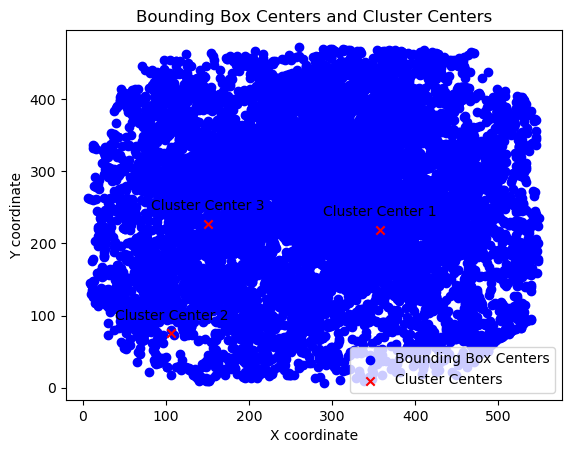

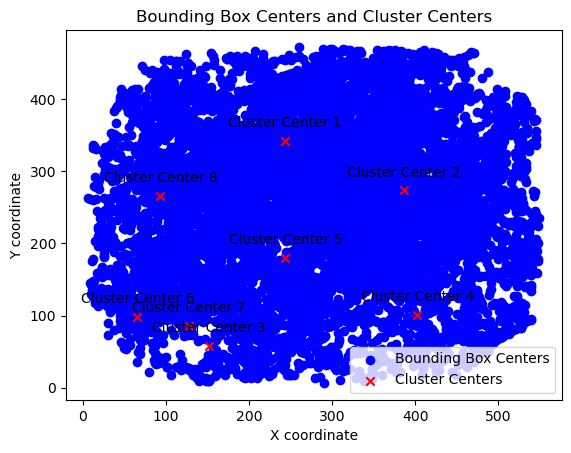

In [50]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
# Also, assume that `bounding_boxes` contains your bounding box data.
plot_cluster_centers_with_bbox_centers(centers_3, all_bounding_boxes)
plot_cluster_centers_with_bbox_centers(centers_8, all_bounding_boxes)



### Data augmentation network

In [ ]:
# # Importar las bibliotecas necesarias
# import torch
# from torch import nn
# from torch.optim import Adam
# from torchvision import transforms
# from torchvision.datasets import ImageFolder
# from torch.utils.data import DataLoader
# from cycle_gan_model import Generator, Discriminator  # Suponiendo que tienes implementaciones de Generator y Discriminator
# 
# # Definir transformaciones para las imágenes
# transform = transforms.Compose([
#     transforms.Resize((256, 256)),  # Cambiar al tamaño deseado
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])
# 
# # Cargar los datasets
# # Supongamos que tienes dos carpetas: '/path/to/masks' para máscaras y '/path/to/real_images' para imágenes reales
# dataset_masks = ImageFolder('/path/to/masks', transform=transform)
# dataset_real_images = ImageFolder('/path/to/real_images', transform=transform)
# 
# # Crear DataLoaders para los datasets
# loader_masks = DataLoader(dataset_masks, batch_size=1, shuffle=True)
# loader_real_images = DataLoader(dataset_real_images, batch_size=1, shuffle=True)
# 
# # Inicializar los modelos GAN
# G_mask_to_image = Generator()  # Generador que convierte máscaras en imágenes
# G_image_to_mask = Generator()  # Generador que convierte imágenes en máscaras
# D_image = Discriminator()  # Discriminador para imágenes
# D_mask = Discriminator()  # Discriminador para máscaras
# 
# # Mover modelos al dispositivo adecuado (CPU o GPU)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# G_mask_to_image.to(device)
# G_image_to_mask.to(device)
# D_image.to(device)
# D_mask.to(device)
# 
# # Definir los optimizadores para los generadores y discriminadores
# optimizer_G = Adam(list(G_mask_to_image.parameters()) + list(G_image_to_mask.parameters()), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D_image = Adam(D_image.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D_mask = Adam(D_mask.parameters(), lr=0.0002, betas=(0.5, 0.999))
# 
# # Definir la función de pérdida (adversarial loss)
# criterion_GAN = nn.MSELoss()
# criterion_cycle = nn.L1Loss()  # Para la consistencia cíclica
# criterion_identity = nn.L1Loss()  # Para la pérdida de identidad (opcional)
# 
# # Bucle de entrenamiento
# for epoch in range(num_epochs):
#     for mask, real_image in zip(loader_masks, loader_real_images):
# 
#         # Preparar los inputs
#         real_image = real_image.to(device)
#         mask = mask.to(device)
# 
#         # Generar una imagen falsa a partir de la máscara
#         fake_image = G_mask_to_image(mask)
# 
#         # Entrenar los discriminadores (D_image y D_mask)
#         # ...
# 
#         # Calcular la pérdida para los generadores (G_mask_to_image y G_image_to_mask)
#         # ...
# 
#         # Retropropagación y optimización para los generadores
#         # ...
# 
#         # Retropropagación y optimización para los discriminadores
#         # ...
# 
# # Guardar los modelos entrenados
# torch.save(G_mask_to_image.state_dict(), 'G_mask_to_image.pth')
# torch.save(G_image_to_mask.state_dict(), 'G_image_to_mask.pth')
# torch.save(D_image.state_dict(), 'D_image.pth')
# torch.save(D_mask.state_dict(), 'D_mask.pth')
# 
# # Generar imágenes para evaluación o más entrenamiento
# G_mask_to_image.eval()
# with torch.no_grad():
#     for mask in loader_masks:
#         mask = mask.to(device)
#         synthetic_image = G_mask_to_image(mask)
#         # Guardar o utilizar synthetic_image


In [23]:
# Train the model
# epoch_losses = []  # List to store epoch loss
# batch_losses = []  # List to store losses for each batch
# 
# best_val_loss = float('inf')  # Initialize best validation loss
# 
# for epoch in range(num_epochs):
#     model.train()
#     epoch_loss = 0  # Keep track of the total loss for this epoch
#     for images, targets in train_loader:
#         # Move images and targets to device
#         images = list(image.to(device) for image in images)
#         targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
#        
#         # Debugging code to check the device of the inputs 
#         # print(f"Device of model parameters: {[p.device for p in model.parameters()]}")
#         # print(f"Device of images: {images[0].device}")
#         # print(f"Device of targets: {targets[0]['boxes'].device}")
# 
#         loss_dict = model(images, targets)
#         losses = sum(loss.to(device) for loss in loss_dict.values())
#         
#         epoch_loss += losses.item()  # Add the batch loss to the total epoch loss
# 
#         # Record the loss for the current batch
#         batch_loss = losses.item()
#         batch_losses.append(batch_loss)
#         
#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()
#         
#     # After training for an epoch, validate
#     val_loss = validate(model, val_loader, device)
#     
#     # Check if this is the best model based on validation loss
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         # Save the best model
#         torch.save(model.state_dict(), 'best_model.pth')
# 
#     # Print out the information
#     print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
#     # Append the epoch loss to the list
#     epoch_losses.append(epoch_loss)
#     # Update the learning rate
#     lr_scheduler.step()
#     # Print learning rate for each parameter group
#     for param_group in optimizer.param_groups:
#         print(f'Learning Rate: {param_group["lr"]:.6f}')

KeyboardInterrupt: 